In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [2]:
digits = load_digits()
titanic = sns.load_dataset('titanic')

titanic = titanic[['survived', 'pclass', 'sex', 'age', 'fare']]
titanic.dropna(inplace=True)

titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

X_c = titanic.drop('survived', axis=1)
y_c = titanic['survived']

print("Digits shape:", digits.data.shape)
print("Titanic shape:", X_c.shape)

Digits shape: (1797, 64)
Titanic shape: (714, 4)


In [3]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=42
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.3, random_state=42
)

In [4]:
log_bin = LogisticRegression(max_iter=5000)
log_bin.fit(X_train_c, y_train_c)

pred_log_c = log_bin.predict(X_test_c)

print("Logistic Binary Accuracy:", accuracy_score(y_test_c, pred_log_c))
print(confusion_matrix(y_test_c, pred_log_c))
print(classification_report(y_test_c, pred_log_c))


Logistic Binary Accuracy: 0.7674418604651163
[[102  24]
 [ 26  63]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       126
           1       0.72      0.71      0.72        89

    accuracy                           0.77       215
   macro avg       0.76      0.76      0.76       215
weighted avg       0.77      0.77      0.77       215



In [5]:

log_multi = LogisticRegression(max_iter=5000)
log_multi.fit(X_train_d, y_train_d)

pred_log_d = log_multi.predict(X_test_d)

print("Logistic Multiclass Accuracy:", accuracy_score(y_test_d, pred_log_d))


Logistic Multiclass Accuracy: 0.9685185185185186


In [6]:

svm_bin = SVC()
svm_bin.fit(X_train_c, y_train_c)

pred_svm_c = svm_bin.predict(X_test_c)

print("SVM Binary Accuracy:", accuracy_score(y_test_c, pred_svm_c))
print(confusion_matrix(y_test_c, pred_svm_c))


SVM Binary Accuracy: 0.6511627906976745
[[109  17]
 [ 58  31]]


In [7]:

svm_multi = SVC()
svm_multi.fit(X_train_d, y_train_d)

pred_svm_d = svm_multi.predict(X_test_d)

print("SVM Multiclass Accuracy:", accuracy_score(y_test_d, pred_svm_d))


SVM Multiclass Accuracy: 0.987037037037037


In [8]:
print("Binary F1 Logistic:", f1_score(y_test_c, pred_log_c))
print("Binary F1 SVM:", f1_score(y_test_c, pred_svm_c))

print("Multiclass F1 Logistic:", f1_score(y_test_d, pred_log_d, average='macro'))
print("Multiclass F1 SVM:", f1_score(y_test_d, pred_svm_d, average='macro'))


Binary F1 Logistic: 0.7159090909090909
Binary F1 SVM: 0.45255474452554745
Multiclass F1 Logistic: 0.9685572781782275
Multiclass F1 SVM: 0.9869102479765148


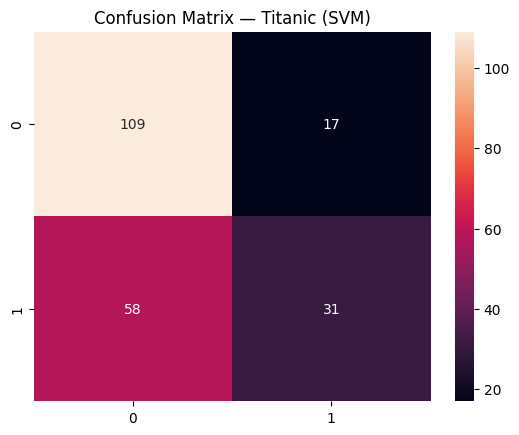

In [9]:
cm = confusion_matrix(y_test_c, pred_svm_c)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix — Titanic (SVM)")
plt.show()